# Exploring the MMSP 2026 LIVE Results

This notebook reproduces the still-image experiments presented in the MMSP 2026 paper 🌐 *ApproxSSIMate: Fast SSIM Estimation from MSE for Image and Video Coding*.

The experiments use the LIVE Image Quality Assessment Database to evaluate ApproxSSIMate across several distortion families, including JPEG, JPEG2000, fast fading, and Gaussian blur.

For each reference image, the reference-dependent statistic \(k\) is computed once and reused across all corresponding distorted images. For each distorted image, we compute global MSE, measured SSIM, and the ApproxSSIMate estimate derived from \(k\) and MSE.

The notebook walks through dataset parsing, reference-statistics computation, objective metric evaluation, and reproduction of the distortion-specific approximation-error results.

## Table of Contents

- [1. Setup](#1-setup)
- [2. Parse the LIVE dataset](#2-parse-the-live-dataset)
- [3. Compute reference statistics](#3-compute-reference-statistics)
- [4. Compute measured MSE and SSIM](#4-compute-measured-mse-and-ssim)
- [5. Compute ApproxSSIMate estimates](#5-compute-approxssimate-estimates)
- [6. Analyze approximation error](#6-analyze-approximation-error)
- [7. Summarize approximation accuracy](#7-summarize-approximation-accuracy)

## 1. Setup

Import the required packages and define the paths used throughout the notebook.

The LIVE dataset is expected to be available locally. The notebook discovers the reference and distorted images from the dataset folders and stores intermediate results under `data/results/live/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.metrics import structural_similarity
from tqdm import tqdm

from approxssimate import (
    approx_ssim_from_k_mse,
    compute_k,
)

ROOT = Path(".")
DATA_DIR = ROOT / "data"
RESULTS_DIR = DATA_DIR / "results" / "live"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

LIVE_ROOT = Path.home() / "Datasets" / "LIVE Image Quality Assessment Database"

REF_DIR = LIVE_ROOT / "refimgs"

DISTORTION_DIRS = {
    "jpeg": LIVE_ROOT / "jpeg",
    "jp2k": LIVE_ROOT / "jp2k",
    "fastfading": LIVE_ROOT / "fastfading",
    "gblur": LIVE_ROOT / "gblur",
}

DISTORTION_COLORS = {
    "jpeg": "#56B4D3",
    "jp2k": "#A8C95F",
    "fastfading": "#E89AB6",
    "gblur": "#F1C75B",
}

print(f"LIVE root: {LIVE_ROOT}")
print(f"Reference images: {len(list(REF_DIR.glob('*')))}")

for name, path in DISTORTION_DIRS.items():
    print(f"{name:<10}: {len(list(path.glob('*')))} images")

LIVE root: /Users/luctrudeau/Datasets/LIVE Image Quality Assessment Database
Reference images: 30
jpeg      : 235 images
jp2k      : 229 images
fastfading: 176 images
gblur     : 176 images


## 2. Parse the LIVE dataset

Each LIVE distortion folder contains an `info.txt` file that maps every distorted image to its corresponding reference image.

We use these mappings to build a single table containing the distortion type, reference image, and distorted image path for every sample in the experiment.

In [2]:
def parse_info_file(distortion_name, distortion_dir, ref_dir):
    """Parse a LIVE distortion info.txt file."""
    info_path = distortion_dir / "info.txt"
    rows = []

    with open(info_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 3:
                raise ValueError(
                    f"Unexpected line in {info_path}: {line}"
                )

            ref_name, dist_name, _ = parts

            rows.append(
                {
                    "distortion": distortion_name,
                    "ref_name": ref_name,
                    "dist_name": dist_name,
                    "ref_path": str(ref_dir / ref_name),
                    "dist_path": str(distortion_dir / dist_name),
                }
            )

    return pd.DataFrame(rows)


dfs = [
    parse_info_file(
        distortion_name,
        distortion_dir,
        REF_DIR,
    )
    for distortion_name, distortion_dir in DISTORTION_DIRS.items()
]

df_pairs = pd.concat(dfs, ignore_index=True)

df_pairs

,distortion,ref_name,dist_name,ref_path,dist_path
0,jpeg,womanhat.bmp,img1.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...
1,jpeg,churchandcapitol.bmp,img2.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...
2,jpeg,lighthouse.bmp,img3.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...
3,jpeg,churchandcapitol.bmp,img4.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...
4,jpeg,carnivaldolls.bmp,img5.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...
...,...,...,...,...,...
803,gblur,house.bmp,img160.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...
804,gblur,sailing4.bmp,img127.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...
805,gblur,sailing4.bmp,img76.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...
806,gblur,sailing4.bmp,img89.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...


## 3. Compute reference statistics

ApproxSSIMate derives a reference-dependent scaling factor \(k\) from the undistorted image.

Since every LIVE reference image is reused across many distorted versions, \(k\) only needs to be computed once per reference. The resulting values are then associated with every corresponding distorted image.

In [3]:
def load_gray_image(path):
    img = imread(path)
    if img.ndim == 3:
        img = np.round(rgb2gray(img) * 255.0)
    return img.astype(np.float64)

rows = []

for ref_path in tqdm(
    sorted(REF_DIR.glob("*.bmp")),
    desc="Computing k",
):
    ref_img = load_gray_image(ref_path)

    rows.append(
        {
            "ref_name": ref_path.name,
            "k": compute_k(ref_img),
        }
    )

df_k = pd.DataFrame(rows)

df_pairs = df_pairs.merge(
    df_k,
    on="ref_name",
    how="left",
    validate="many_to_one",
)

df_k

Computing k: 100%|██████████| 29/29 [00:00<00:00, 130.71it/s]


,ref_name,k
0,bikes.bmp,0.001124
1,building2.bmp,0.000584
2,buildings.bmp,0.000836
3,caps.bmp,0.004213
4,carnivaldolls.bmp,0.001357
5,cemetry.bmp,0.001245
6,churchandcapitol.bmp,0.001245
7,coinsinfountain.bmp,0.001657
8,dancers.bmp,0.000910
9,flowersonih35.bmp,0.000676


## 4. Compute measured MSE and SSIM

For each distorted image, we load the corresponding reference image and compute:

- global mean squared error (MSE), and
- measured SSIM using a $7 \times 7$ window and an 8-bit data range.

These measurements are cached to disk because SSIM is the most expensive part of the LIVE experiment.

In [4]:
METRICS_PATH = RESULTS_DIR / "live_metrics.csv"

if METRICS_PATH.exists():
    df_metrics = pd.read_csv(METRICS_PATH)

else:
    rows = []

    for row in tqdm(
        df_pairs.itertuples(index=False),
        total=len(df_pairs),
        desc="Computing MSE and SSIM",
    ):
        ref_img = load_gray_image(row.ref_path)
        dist_img = load_gray_image(row.dist_path)

        if ref_img.shape != dist_img.shape:
            raise ValueError(
                f"Image size mismatch: {row.ref_name} vs {row.dist_name}"
            )

        mse = np.mean((ref_img - dist_img) ** 2)

        ssim = structural_similarity(
            ref_img,
            dist_img,
            data_range=255,
            win_size=7,
        )

        rows.append(
            {
                "distortion": row.distortion,
                "ref_name": row.ref_name,
                "dist_name": row.dist_name,
                "mse": mse,
                "ssim": ssim,
            }
        )

    df_metrics = pd.DataFrame(rows)
    df_metrics.to_csv(METRICS_PATH, index=False)

df_metrics

,distortion,ref_name,dist_name,mse,ssim
0,jpeg,womanhat.bmp,img1.bmp,54.721557,0.801212
1,jpeg,churchandcapitol.bmp,img2.bmp,68.826361,0.907724
2,jpeg,lighthouse.bmp,img3.bmp,0.000000,1.000000
3,jpeg,churchandcapitol.bmp,img4.bmp,288.074788,0.700258
4,jpeg,carnivaldolls.bmp,img5.bmp,0.000000,1.000000
...,...,...,...,...,...
803,gblur,house.bmp,img160.bmp,0.000000,1.000000
804,gblur,sailing4.bmp,img127.bmp,156.796814,0.732136
805,gblur,sailing4.bmp,img76.bmp,101.891520,0.824542
806,gblur,sailing4.bmp,img89.bmp,63.086609,0.893083


In [5]:
df_results = df_pairs.merge(
    df_metrics,
    on=["distortion", "ref_name", "dist_name"],
    how="inner",
    validate="one_to_one",
)

df_results.head()

,distortion,ref_name,dist_name,ref_path,dist_path,k,mse,ssim
0,jpeg,womanhat.bmp,img1.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...,0.003803,54.721557,0.801212
1,jpeg,churchandcapitol.bmp,img2.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...,0.001245,68.826361,0.907724
2,jpeg,lighthouse.bmp,img3.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...,0.002218,0.000000,1.000000
3,jpeg,churchandcapitol.bmp,img4.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...,0.001245,288.074788,0.700258
4,jpeg,carnivaldolls.bmp,img5.bmp,/Users/luctrudeau/Datasets/LIVE Image Quality ...,/Users/luctrudeau/Datasets/LIVE Image Quality ...,0.001357,0.000000,1.000000


## 5. Compute ApproxSSIMate estimates

With the reference statistic \(k\) and measured MSE available for every distorted image, we can now estimate SSIM using ApproxSSIMate.

For this still-image experiment, each sample produces a single estimate directly from its reference-derived \(k\) value and global MSE.

In [6]:
df_results["approx_ssim"] = approx_ssim_from_k_mse(
    df_results["k"].to_numpy(),
    df_results["mse"].to_numpy(),
)

df_results["error"] = (
    df_results["approx_ssim"] - df_results["ssim"]
)

df_results[
    [
        "distortion",
        "ref_name",
        "dist_name",
        "mse",
        "ssim",
        "approx_ssim",
        "error",
    ]
].head()

,distortion,ref_name,dist_name,mse,ssim,approx_ssim,error
0,jpeg,womanhat.bmp,img1.bmp,54.721557,0.801212,0.791882,-0.009330
1,jpeg,churchandcapitol.bmp,img2.bmp,68.826361,0.907724,0.914306,0.006582
2,jpeg,lighthouse.bmp,img3.bmp,0.000000,1.000000,1.000000,0.000000
3,jpeg,churchandcapitol.bmp,img4.bmp,288.074788,0.700258,0.641325,-0.058933
4,jpeg,carnivaldolls.bmp,img5.bmp,0.000000,1.000000,1.000000,0.000000


## 6. Analyze approximation error

We now examine the ApproxSSIMate error separately for each LIVE distortion family.

The error is defined as the estimated SSIM minus the measured SSIM. Looking at the distribution by distortion type helps show where the approximation is most accurate and where systematic bias may remain.

In [7]:
summary_df = (
    df_results
    .groupby("distortion", as_index=False)
    .agg(
        samples=("error", "size"),
        mean_error=("error", "mean"),
        mae=("error", lambda x: np.mean(np.abs(x))),
        rmse=("error", lambda x: np.sqrt(np.mean(x**2))),
    )
)

summary_df

,distortion,samples,mean_error,mae,rmse
0,fastfading,174,-0.109709,0.113315,0.184969
1,gblur,174,-0.117887,0.118140,0.190524
2,jp2k,227,-0.007836,0.036461,0.066144
3,jpeg,233,-0.053588,0.060721,0.134137


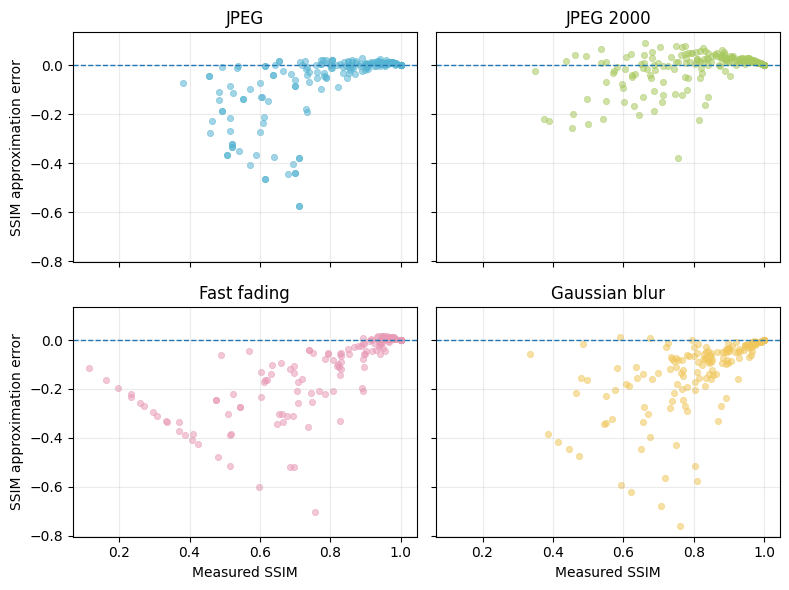

In [9]:
distortions = ["jpeg", "jp2k", "fastfading", "gblur"]

titles = {
    "jpeg": "JPEG",
    "jp2k": "JPEG 2000",
    "fastfading": "Fast fading",
    "gblur": "Gaussian blur",
}

DISTORTION_COLORS = {
    "jpeg": "#56B4D3",
    "jp2k": "#A8C95F",
    "fastfading": "#E89AB6",
    "gblur": "#F1C75B",
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 6),
    sharex=True,
    sharey=True,
)

for ax, distortion in zip(axes.flat, distortions):
    subset = df_results[
        df_results["distortion"] == distortion
    ]

    ax.scatter(
        subset["ssim"],
        subset["error"],
        s=20,
        facecolors=DISTORTION_COLORS[distortion],
        edgecolors=DISTORTION_COLORS[distortion],
        alpha=0.55,
        linewidth=0.6,
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
    )

    ax.set_title(titles[distortion])
    ax.grid(alpha=0.25)

axes[0, 0].set_ylabel("SSIM approximation error")
axes[1, 0].set_ylabel("SSIM approximation error")

axes[1, 0].set_xlabel("Measured SSIM")
axes[1, 1].set_xlabel("Measured SSIM")

fig.tight_layout()
plt.show()

## 7. Summarize approximation accuracy

The scatter plots show how the error behaves across quality levels. To summarize the overall accuracy for each distortion family, we report the mean error, mean absolute error, and root-mean-square error.

In [ ]:
table_df = df_results.copy()
table_df["abs_error"] = np.abs(table_df["error"])

summary_df = (
    table_df
    .groupby("distortion")
    .agg(
        N=("error", "size"),
        Median=("abs_error", "median"),
        **{
            "95th pct.": (
                "abs_error",
                lambda x: np.percentile(x, 95),
            ),
            "Max": ("abs_error", "max"),
            "Mean signed": ("error", "mean"),
        },
    )
    .reset_index()
)

summary_df["distortion"] = summary_df["distortion"].map(
    {
        "jpeg": "JPEG",
        "jp2k": "JPEG2000",
        "fastfading": "Fast fading",
        "gblur": "Gaussian blur",
    }
)

summary_df.style.format(
    {
        "Median": "{:.3f}",
        "95th pct.": "{:.3f}",
        "Max": "{:.3f}",
        "Mean signed": "{:+.3f}",
    }
)

,distortion,N,Median,95th pct.,Max,Mean signed
0,Fast fading,174,0.042,0.388,0.704,-0.110
1,Gaussian blur,174,0.066,0.444,0.761,-0.118
2,JPEG2000,227,0.019,0.159,0.380,-0.008
3,JPEG,233,0.010,0.369,0.575,-0.054
